[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Adapting LLMs: Instruction Tuning with LoRA

In the previous notebook we put the same question to `Qwen3-0.6B-Base` and `Qwen3-0.6B` and got two very different answers: the base model continued the document, the instruct model answered the person.  We attributed the difference to post-training and moved on.

Now we do it ourselves.  By the end of this notebook we will have taken the **base** model and, on a laptop, in a few minutes, turned it into something that answers instructions — reproducing stage 2 of notebook 1's pipeline (supervised fine-tuning) with our own training loop.  The tool that makes this possible at laptop scale is **LoRA**, and it is a genuinely elegant idea: freeze the entire pretrained model and train a tiny low-rank correction alongside it.

Three things to build, in the usual order — arithmetic first, then the mechanism by hand, then the real run:

1. Work out *why* ordinary fine-tuning does not fit, in gigabytes.
2. Implement LoRA from scratch on a single `nn.Linear`, and verify it behaves as advertised.
3. Use `peft` to apply it to the whole model, instruction-tune on a small dataset, and compare the model against its own former self.

In [1]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

# `peft` and `datasets` come from this module's environment.yml:
#     conda env update -f environment.yml --prune
import gc
import math
import os
import time

import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

BLUE, GREEN, IO = '#cdddec', '#d0e3d4', '#ededed'
AMBER, TX = '#c0662f', '#333333'

# As in notebook 4: if the kernel dies mid-cell on Apple silicon, set this to
# True and restart.  Training touches more of the backend than inference does,
# so if any notebook in this module is going to hit an MPS gap, it is this one.
FORCE_CPU = False

device = ('cpu' if FORCE_CPU
          else 'cuda' if torch.cuda.is_available()
          else 'mps' if torch.backends.mps.is_available() else 'cpu')
torch.manual_seed(0)
print(f'Using {device} device')

# The pretrained-only model from notebook 4.  Fine-tuning cost scales with
# model size, so if the training cell below is too slow, the single most
# effective change is a smaller base model:
BASE = 'HuggingFaceTB/SmolLM2-360M'     # ~40% the size, ~2.5x faster
# See notebook 4's note on choosing a model for the alternatives.
#BASE = 'Qwen/Qwen3-0.6B-Base'


Using mps device


## Why not just fine-tune it?

Fine-tuning meant, in the BERT notebook, letting gradients flow into every weight.  That worked there because DistilBERT is 66M parameters.  Here is the same plan costed out for models of increasing size, counting what an Adam-family optimizer actually has to hold in memory:

* the **weights** themselves — 4 bytes per parameter in float32;
* a **gradient** for every weight — another 4 bytes;
* Adam's **two moment estimates** per weight — 8 more bytes.

So roughly **16 bytes per parameter**, before activations.

In [2]:
def full_ft_memory(n_params):
    """Bytes for weights + grads + Adam moments, in float32."""
    return n_params * (4 + 4 + 4 + 4)

print(f'{"model":22s} {"parameters":>12s} {"full fine-tuning":>18s}')
for name, n in [('DistilBERT (attention module)', 66e6), ('our GPT (notebook 3)', 4.2e6),
                ('Qwen3-0.6B', 0.6e9), ('Llama-3-8B', 8e9), ('Llama-3-70B', 70e9)]:
    print(f'{name:22s} {n/1e9:11.3f}B {full_ft_memory(n)/1e9:15.1f} GB')

model                    parameters   full fine-tuning
DistilBERT (module 4)        0.066B             1.1 GB
our GPT (notebook 3)         0.004B             0.1 GB
Qwen3-0.6B                   0.600B             9.6 GB
Llama-3-8B                   8.000B           128.0 GB
Llama-3-70B                 70.000B          1120.0 GB


Our 0.6B model is right at the edge of comfortable on a laptop — and it is *tiny* by current standards.  At 8B the plan needs a large data-center GPU; at 70B it needs a cluster.  And this is for one task: full fine-tuning also produces a complete new copy of the weights per task, so ten tasks means ten times 1.2 GB to store and serve.

**LoRA** (Low-Rank Adaptation; Hu et al., 2021) attacks both problems with one observation: the *update* a fine-tune applies to a weight matrix has much lower intrinsic rank than the matrix itself.  You do not need a full $d \times k$ correction; a thin one will do.  So freeze $W$ and write the adapted weight as

$$W' \;=\; W + \Delta W \;=\; W + \frac{\alpha}{r} B A, \qquad B \in \mathbb{R}^{d \times r},\; A \in \mathbb{R}^{r \times k},\; r \ll \min(d, k).$$

Only $A$ and $B$ are trained.  Three consequences follow immediately, and they are the whole reason LoRA took over:

* **Trainable parameters collapse.**  A $1024 \times 1024$ matrix has ~1M parameters; its rank-8 correction has $8 \times (1024 + 1024) \approx 16$K — about 1.6%.  Optimizer state shrinks by the same factor, because there is no optimizer state for frozen weights.
* **Initialize $B = 0$** and $\Delta W = 0$, so the adapted model starts *exactly* equal to the pretrained one.  Training then departs from a known-good starting point rather than a perturbed one.
* **The adapter is a separate, tiny file.**  Ship one 1.2 GB base model plus a few megabytes per task, and swap adapters at will. You can also *merge* $\frac{\alpha}{r}BA$ into $W$ afterwards for zero added inference cost.

Rank $r$ and scale $\alpha$ are the two knobs. $r$ sets the capacity of the correction; $\alpha/r$ scales it so that changing $r$ does not force you to re-tune the learning rate.

## LoRA by hand

Before reaching for a library, build it — it is about fifteen lines.

In [3]:
class LoRALinear(nn.Module):
    """A frozen nn.Linear plus a trainable low-rank correction."""
    def __init__(self, base: nn.Linear, r=8, alpha=16):
        super().__init__()
        self.base = base
        for p in self.base.parameters():        # the pretrained weights are frozen
            p.requires_grad = False
        self.r, self.scaling = r, alpha / r
        # A: random, small.  B: zeros -> the correction starts at exactly zero.
        self.A = nn.Parameter(torch.randn(r, base.in_features) * 0.01)
        self.B = nn.Parameter(torch.zeros(base.out_features, r))

    def forward(self, x):
        return self.base(x) + self.scaling * F.linear(F.linear(x, self.A), self.B)

    def merged_weight(self):
        """W + (alpha/r) B A -- a single matrix, for inference."""
        return self.base.weight + self.scaling * (self.B @ self.A)


torch.manual_seed(0)
base_layer = nn.Linear(1024, 1024)
lora_layer = LoRALinear(base_layer, r=8, alpha=16)
x = torch.randn(4, 1024)

# 1. at initialization the wrapped layer must be an exact no-op
assert torch.allclose(lora_layer(x), base_layer(x), atol=1e-6)
print('at init: output identical to the frozen layer  (because B = 0)')

# 2. only A and B carry gradients
trainable = sum(p.numel() for p in lora_layer.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in lora_layer.parameters() if not p.requires_grad)
print(f'trainable {trainable:,} / {trainable + frozen:,} parameters '
      f'({100 * trainable / (trainable + frozen):.2f}%)')

# 3. after a step, the layer has changed -- and the merged matrix agrees exactly
opt = torch.optim.AdamW([p for p in lora_layer.parameters() if p.requires_grad], lr=1e-2)
lora_layer(x).square().mean().backward()
opt.step()
assert not torch.allclose(lora_layer(x), base_layer(x), atol=1e-4)
merged = F.linear(x, lora_layer.merged_weight(), base_layer.bias)
assert torch.allclose(lora_layer(x), merged, atol=1e-4)
print('after one step: behavior changed, and merging reproduces it exactly')

at init: output identical to the frozen layer  (because B = 0)
trainable 16,384 / 1,065,984 parameters (1.54%)
after one step: behavior changed, and merging reproduces it exactly


Those three assertions are the specification of LoRA, and they are worth stating in words because each one is a claim people get wrong:

1. **At initialization it changes nothing.**  A LoRA-wrapped model is bit-for-bit the pretrained model, so any degradation you see later is something training did, not something the wrapper did.
2. **The frozen weights hold no optimizer state.**  That is where the memory saving comes from — not from the parameter count alone.
3. **The correction can be folded back into $W$.**  LoRA is a training-time trick; at inference you can pay nothing for it.

## The real thing: `peft`

`peft` does exactly what we just wrote, applied to chosen submodules throughout the network. The one decision it asks of us is *which* matrices to adapt.  Common practice is the attention projections; adapting the MLP too gives more capacity for more parameters.  We take the four attention projections.

In [4]:
from peft import LoraConfig, get_peft_model

tok = AutoTokenizer.from_pretrained(BASE)
model = AutoModelForCausalLM.from_pretrained(BASE, torch_dtype=torch.float32).to(device)

lora_cfg = LoraConfig(
    r=8, lora_alpha=16, lora_dropout=0.05, bias='none', task_type='CAUSAL_LM',
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj'])
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

adapter_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\noptimizer state for the adapter: '
      f'{adapter_params * 8 / 1e6:.1f} MB   (vs '
      f'{sum(p.numel() for p in model.parameters()) * 8 / 1e9:.1f} GB for a full fine-tune)')

trainable params: 1,638,400 || all params: 363,459,520 || trainable%: 0.4508

optimizer state for the adapter: 13.1 MB   (vs 2.9 GB for a full fine-tune)


Under one percent of the parameters are trainable, and the optimizer state is measured in megabytes rather than gigabytes.  That is the entire reason this notebook runs on your laptop.

## The data: instructions and responses

Instruction tuning needs examples of the behavior we want: a request, and a good response to it.  We use a small slice of **Alpaca** (52K instruction–response pairs generated with GPT-3.5), which is the dataset that popularized this recipe for small open models.

The formatting is where the real subtlety lives.  We build each example as `prompt + response`, and then — this is the part that matters — compute the loss **only on the response tokens**.  Setting the prompt's labels to `-100` (PyTorch's "ignore" index) tells the model: do not spend capacity learning to generate instructions, learn to generate *answers to* instructions.  Train on the whole string instead and you get a model that cheerfully writes its own questions.

In [5]:
from datasets import load_dataset

N_TRAIN = 800          # a small slice is enough to change behavior visibly
MAX_LEN = 320

raw = load_dataset('tatsu-lab/alpaca', split=f'train[:{N_TRAIN + 40}]')

def format_prompt(instruction, context=''):
    """Our SFT template -- deliberately simple and explicit."""
    if context:
        return (f'### Instruction:\n{instruction}\n\n'
                f'### Input:\n{context}\n\n### Response:\n')
    return f'### Instruction:\n{instruction}\n\n### Response:\n'

def encode_example(row):
    """Tokenize prompt+response; mask the prompt out of the loss."""
    prompt = format_prompt(row['instruction'], row['input'])
    prompt_ids = tok(prompt, add_special_tokens=False)['input_ids']
    resp_ids = tok(row['output'], add_special_tokens=False)['input_ids']
    resp_ids = resp_ids + [tok.eos_token_id]          # teach it to stop
    ids = (prompt_ids + resp_ids)[:MAX_LEN]
    labels = ([-100] * len(prompt_ids) + resp_ids)[:MAX_LEN]
    return {'input_ids': ids, 'labels': labels}

examples = [encode_example(r) for r in raw]
train_examples, eval_examples = examples[:N_TRAIN], examples[N_TRAIN:]
held_out = raw[N_TRAIN:]           # the same rows, unencoded, for eyeballing later

ex = train_examples[0]
n_masked = sum(1 for l in ex['labels'] if l == -100)
print(f'{len(train_examples)} training examples, {len(eval_examples)} eval')
print(f'example: {len(ex["input_ids"])} tokens, {n_masked} masked out of the loss\n')
print(tok.decode(ex['input_ids'][:120]))

800 training examples, 40 eval
example: 61 tokens, 17 masked out of the loss

### Instruction:
Give three tips for staying healthy.

### Response:
1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. 
2. Exercise regularly to keep your body active and strong. 
3. Get enough sleep and maintain a consistent sleep schedule.<|endoftext|>


In [6]:
def collate(batch):
    """Pad a batch to equal length; padding is ignored by both mask and loss."""
    n = max(len(b['input_ids']) for b in batch)
    pad_id = tok.pad_token_id if tok.pad_token_id is not None else tok.eos_token_id
    input_ids, labels, attn = [], [], []
    for b in batch:
        k = n - len(b['input_ids'])
        input_ids.append(b['input_ids'] + [pad_id] * k)
        labels.append(b['labels'] + [-100] * k)          # never train on padding
        attn.append([1] * len(b['input_ids']) + [0] * k)  # never attend to it
    return (torch.tensor(input_ids), torch.tensor(labels), torch.tensor(attn))

xb, yb, mb = collate(train_examples[:4])
print('input_ids', tuple(xb.shape), '| labels', tuple(yb.shape),
      '| attention_mask', tuple(mb.shape))
print('label positions kept per row:', (yb != -100).sum(1).tolist())
print('attention positions per row :', mb.sum(1).tolist())

input_ids (4, 96) | labels (4, 96) | attention_mask (4, 96)
label positions kept per row: [44, 13, 66, 79]
attention positions per row : [61, 30, 83, 96]


`transformers` shifts the labels internally, so passing `labels=` computes exactly the loss of notebook 1 — cross-entropy on next-token prediction — restricted to the positions we left unmasked.  Nothing about the objective has changed since notebook 3.  The only differences are *which* tokens contribute, and *which* parameters can move.

## Training

A plain loop, as in notebook 3: AdamW, cosine decay after a short warmup, gradient clipping.  Gradient accumulation gives an effective batch of 4 while only two sequences are ever in memory.

Two departures from notebook 3's loop are worth noting.

**We report perplexity, not just loss.**  Same quantity, but $e^{\mathcal{L}}$ is the one with an interpretation (notebook 2): the effective number of tokens the model is choosing between at each position of a response.  And we compute it the careful way — accumulate total NLL and total supervised tokens, divide once.  Averaging the per-batch losses instead would weight a batch containing a five-token answer the same as one containing a two-hundred-token answer.

**Budget your patience.**  This is the most expensive cell in the module: every step is a forward *and* backward pass through 0.6B parameters, and on a laptop CPU that runs on the order of a minute per step.  The defaults below (40 steps, sequences capped at `MAX_LEN`) are deliberately small — as you will see from the curve, the behavior we are installing is learned early, and the later steps mostly confirm it.  The cell prints a per-step timing estimate after step 2 so you can decide whether to let it finish or interrupt and lower `MAX_STEPS`.  On a CUDA GPU (including a free Colab one) the same run takes a couple of minutes, and `MAX_STEPS = 150` becomes reasonable.

In [7]:
MICRO_BATCH, ACCUM_STEPS = 2, 2      # effective batch of 4 sequences
MAX_STEPS, WARMUP, LR = 40, 5, 2e-4
EVAL_EVERY, EVAL_SEQS = 10, 8

@torch.no_grad()
def eval_ppl(examples, n_seqs=EVAL_SEQS, seed=0):
    """Token-weighted loss and perplexity on a fixed random sample.

    We accumulate total NLL and total supervised tokens and divide once -- the
    same discipline as notebook 2.  Averaging per-batch losses instead would
    let a batch with five response tokens count as much as one with two
    hundred.  The sample is drawn with a fixed seed, so the number means the
    same thing at every evaluation."""
    model.eval()
    idx = np.random.default_rng(seed).permutation(len(examples))[:n_seqs]
    total_nll, total_tok = 0.0, 0
    for i in range(0, len(idx), MICRO_BATCH):
        xb, yb, mb = collate([examples[j] for j in idx[i:i + MICRO_BATCH]])
        out = model(input_ids=xb.to(device), attention_mask=mb.to(device),
                    labels=yb.to(device))
        n = int((yb[:, 1:] != -100).sum())    # positions the loss averaged over
        total_nll += out.loss.item() * n
        total_tok += n
    model.train()
    nll = total_nll / total_tok
    return nll, math.exp(nll)

def lr_at(step):
    if step < WARMUP:
        return LR * (step + 1) / WARMUP
    prog = (step - WARMUP) / max(1, MAX_STEPS - WARMUP)
    return 0.1 * LR + 0.45 * LR * (1 + math.cos(math.pi * prog))

def report(step, elapsed=None):
    tr_nll, tr_ppl = eval_ppl(train_examples)
    ev_nll, ev_ppl = eval_ppl(eval_examples)
    history.append((step, tr_ppl, ev_ppl))
    t = '' if elapsed is None else f' | {elapsed:5.0f}s'
    print(f'step {step:3d} | train loss {tr_nll:.3f}  PPL {tr_ppl:5.2f} '
          f'| held-out loss {ev_nll:.3f}  PPL {ev_ppl:5.2f}{t}')

params = [p for p in model.parameters() if p.requires_grad]
opt = torch.optim.AdamW(params, lr=LR, weight_decay=0.0)
rng = np.random.default_rng(0)

history = []
report(0)          # the control: at step 0 the adapter is still a no-op

model.train()
t0 = time.time()
for step in range(1, MAX_STEPS + 1):
    for g in opt.param_groups:
        g['lr'] = lr_at(step)
    opt.zero_grad(set_to_none=True)
    for _ in range(ACCUM_STEPS):                      # gradient accumulation
        idx = rng.integers(0, len(train_examples), MICRO_BATCH)
        xb, yb, mb = collate([train_examples[i] for i in idx])
        out = model(input_ids=xb.to(device), attention_mask=mb.to(device),
                    labels=yb.to(device))
        (out.loss / ACCUM_STEPS).backward()
    torch.nn.utils.clip_grad_norm_(params, 1.0)
    opt.step()

    if step == 2:      # calibrate before committing to the whole run
        per_step = (time.time() - t0) / 2
        print(f'  ~{per_step:.0f}s per step -> roughly '
              f'{per_step * MAX_STEPS / 60:.0f} min for {MAX_STEPS} steps, '
              f'plus evaluations\n')
    if step % EVAL_EVERY == 0:
        report(step, time.time() - t0)

print(f'\nfinished in {(time.time() - t0)/60:.1f} min')

# Release the final step's activations.  Without this, `out` (and the batch
# tensors) stay alive in the notebook's namespace holding a complete autograd
# graph, which pins a large amount of device memory for the rest of the
# session -- enough, on a GPU, to make a later cell fail to allocate.
del out, xb, yb, mb
opt.zero_grad(set_to_none=True)
gc.collect()
if device == 'mps':
    torch.mps.empty_cache()
elif device == 'cuda':
    torch.cuda.empty_cache()

step   0 | train loss 1.437  PPL  4.21 | held-out loss 1.615  PPL  5.03
  ~1s per step -> roughly 1 min for 40 steps, plus evaluations

step  10 | train loss 1.406  PPL  4.08 | held-out loss 1.604  PPL  4.97 |    10s
step  20 | train loss 1.384  PPL  3.99 | held-out loss 1.582  PPL  4.87 |    22s
step  30 | train loss 1.366  PPL  3.92 | held-out loss 1.566  PPL  4.79 |    33s
step  40 | train loss 1.361  PPL  3.90 | held-out loss 1.561  PPL  4.76 |    45s

finished in 0.8 min


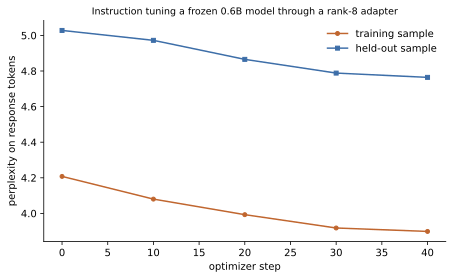

In [8]:
steps, tr, ev = zip(*history)
fig, ax = plt.subplots(figsize=(6.4, 4))
ax.plot(steps, tr, 'o-', color=AMBER, label='training sample', markersize=4)
ax.plot(steps, ev, 's-', color='#3d6ea8', label='held-out sample', markersize=4)
ax.set_xlabel('optimizer step')
ax.set_ylabel('perplexity on response tokens')
ax.set_title('Instruction tuning a frozen 0.6B model through a rank-8 adapter',
             fontsize=9.5)
ax.legend(frameon=False); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout();

Two features of this curve deserve more attention than the fact that it goes down.

**Almost everything happens immediately.**  The perplexity drops in the first evaluations and then flattens.  That is a real result, not a failed run: we are not teaching the model *language* — pretraining did that — we are teaching it a **format**, namely that text after `### Response:` is a direct answer that ends.  A format is low-information, so a rank-8 correction learns it in a few dozen steps.  Contrast notebook 3, where millions of tokens bought a model that could barely finish a sentence.  This is the practical meaning of "capability comes from pretraining".

**The held-out numbers may come out *below* the training numbers**, which looks alarming and is not.  Check the `step 0` row: the adapter is initialized to zero there, so the model evaluated on both samples is *bit-for-bit identical* — any gap at step 0 is a property of the two samples, not of training.  Alpaca responses vary enormously in length and difficulty, and with a handful of sequences per estimate the two subsets are simply not equally hard.  The step-0 row is a built-in control: read the *change* in each curve from its own starting point, and ignore the vertical offset between them.  (If you want them comparable in absolute terms, raise `EVAL_SEQS` substantially — and pay for it in time.)

## Did the behavior actually change?

The loss curve is evidence; the behavior is the result.  `peft` lets us switch the adapter off and on with a context manager, so we can put an identical prompt to the *same object* with and without the correction — the cleanest possible before/after.

**If the kernel dies in the next cell on Apple silicon**, you have hit an MPS problem rather than a bug in the logic — and the cell above already applies the two fixes that matter.  It is worth knowing what they are, because both are general lessons about running models on a GPU from a notebook.

*Memory outlives the cell that allocated it.*  After the training loop, the variables from the final step (`out` in particular) are still bound in the notebook's namespace, and `out` holds a reference to the whole autograd graph — every activation from that forward pass, pinned on the device.  Training itself never notices; the *next* cell, trying to allocate for generation, does.  Deleting those names and emptying the allocator cache is the fix, and it is a habit worth forming: in a notebook, nothing goes out of scope on its own.

*Reductions over non-contiguous views.*  `out.logits[0, -1]` is a slice, not a fresh tensor, and `argmax` over such a view is a known weak spot in the Metal backend.  Calling `.float()` first forces a contiguous copy, which is why the equivalent loop in notebook 4 has always been safe.

If it still crashes, two escalations, in order: launch Jupyter with `PYTORCH_ENABLE_MPS_FALLBACK=1` set in the environment, which makes unimplemented operations fall back to the CPU instead of aborting the process; or set `FORCE_CPU = True` at the top and restart.  Note the asymmetry that makes this confusing to debug — a Metal-level failure kills the interpreter, so you get "the kernel appears to have died" rather than a Python traceback pointing at the line responsible.

In [ ]:
@torch.no_grad()
def respond(instruction, context='', adapter=True, max_new_tokens=90, seed=0):
    """Greedy continuation of our SFT prompt, with or without the adapter.

    Returns the text plus two things worth measuring: how many tokens it took,
    and whether it stopped on its own (emitted <eos>) or simply ran out of
    budget.  Stopping is a learned behavior, so it is part of the result."""
    model.eval()
    torch.manual_seed(seed)
    prompt = format_prompt(instruction, context)
    ids = tok(prompt, return_tensors='pt')['input_ids'].to(device)
    start = ids.shape[1]
    stopped = False
    for _ in range(max_new_tokens):
        try:                                  # only the last position is needed
            out = model(ids, logits_to_keep=1)
        except TypeError:
            out = model(ids)
        # .float() forces a contiguous copy before argmax; reducing over a
        # non-contiguous view is a known source of trouble on the MPS backend.
        nxt = out.logits[0, -1].float().argmax().view(1, 1)
        if nxt.item() == tok.eos_token_id:
            stopped = True
            break
        ids = torch.cat([ids, nxt], dim=1)
    text = tok.decode(ids[0, start:], skip_special_tokens=True).strip()
    return text, ids.shape[1] - start, stopped

PROBES = ['Name three uses of a paperclip.',
          'Explain what a transformer is in one sentence.',
          'What is the capital of Colorado?']

def show(label, result):
    text, n, stopped = result
    flag = 'stopped on its own' if stopped else 'still going at the token limit'
    print(f'  {label}: [{n:2d} tokens, {flag}]')
    print(f'      {text}')

for q in PROBES:
    print(f'=== {q}')
    with model.disable_adapter():                 # the original base model
        show('BASE ', respond(q))
    show('TUNED', respond(q))                     # base + our rank-8 adapter
    print()

Read the bracketed measurements first, then the text.  Three things are visible, and the third is the most important.

**The base model does not know when to stop.**  Every base answer above runs to the token limit; every tuned answer ends on its own.  And look at *how* the base model fills that budget: having answered the question, it writes the next plausible thing in a document that contains an instruction and a response — namely, another instruction and another response.  It invents `### Question 2: Name three uses of a pencil.` and answers that too; it asks itself for the capital of New York.  This is not confusion, it is the next-token objective working exactly as trained: our prompt *looks like* a page of instruction/response pairs, so the most likely continuation of one is another one.  Nothing in pretraining ever taught the model that a response has an end.  The adapter did, because every training target we built ended in `<eos>`.

**"Tuned" does not mean "shorter."**  The tuned answers above are 26, 80 and 8 tokens.  The model did not learn brevity; it learned to terminate *when the answer is complete*, which for a one-sentence explanation is longer than for a one-word fact.  Length is a symptom; the learned behavior is knowing where the boundary is.

**Fine-tuning changed the form of the answer, not its truth.**  Look at the last probe.  "Colorado is the capital of Colorado" is wrong — and both models say it.  The base version at least exposes the mechanism, since it goes on to produce "New York is the capital of New York" and "Texas is the capital of Texas": the model has latched onto a *syntactic pattern* from the prompt rather than retrieving a fact, because a 360M-parameter model simply does not reliably know US state capitals.  Our fine-tuning did nothing about this, and could not have: 40 steps on 800 examples teaches format, and knowledge lives in the pretrained weights.

That last point deserves to be uncomfortable.  Post-training made the wrong answer **shorter, cleaner, and more confident** — eight tokens, well formatted, terminated, indistinguishable in shape from the correct answers above it.  The rambling base version is more obviously untrustworthy; the tuned version *looks* authoritative.  Instruction tuning optimizes the appearance of a good response, and appearance and accuracy are separate axes.  This is the mechanism behind a great deal of what gets called "hallucination": a model trained to produce well-formed answers will produce a well-formed answer whether or not it knows one.

(How dramatic this contrast looks depends on which base model you chose.  A larger, more thoroughly pretrained base — `Qwen3-0.6B-Base`, say — already recognizes the `### Instruction:` format and will often answer and stop without any help from us, which makes the demonstration subtler but the underlying point identical.  The weaker the base, the more visible the intervention.)

Two practical notes on shipping this.

In [ ]:
model.save_pretrained('../data/qwen3-0.6b-alpaca-lora')
adapter_bytes = sum(
    os.path.getsize(os.path.join(dp, f))
    for dp, _, fs in os.walk('../data/qwen3-0.6b-alpaca-lora') for f in fs)
base_bytes = sum(p.numel() * 4 for p in model.parameters())
print(f'adapter on disk : {adapter_bytes/1e6:8.1f} MB')
print(f'base model      : {base_bytes/1e9:8.2f} GB in float32')
print(f'ratio           : {base_bytes/adapter_bytes:8.0f}x smaller\n')

# For deployment: fold the correction into W and drop the adapter machinery.
merged = model.merge_and_unload()
print(type(merged).__name__, '-- adapter merged; inference cost is now identical'
      ' to the original model')
# NOTE: merging consumes the peft wrapper, so `respond()` and
# `model.disable_adapter()` above no longer work -- re-run from the peft cell
# if you want to go back to comparing base against adapter.

A few megabytes per task against 2.4 GB of shared weights, which is why a single served base model can back dozens of adapted behaviors: keep the base in memory once and swap adapters per request.  And `merge_and_unload` folds $\frac{\alpha}{r}BA$ into $W$ — the same algebra as our `merged_weight()` above — so the deployed model has no extra layers, no extra latency, and no trace that LoRA was involved.

## What we skipped: preference tuning

We have now done stages 1 and 2 of notebook 1's pipeline: pretraining (notebook 3, from scratch) and supervised instruction tuning (this one).  Stage 3 is **preference tuning**, and it exists because SFT has a ceiling: it can only imitate responses someone wrote down.  It cannot express "this answer is better than that one" — and *comparisons* are both easier for humans to give reliably and closer to what we actually want.

Two approaches dominate:

* **RLHF** (Ouyang et al., 2022): collect human rankings over candidate responses, train a **reward model** to predict them, then optimize the language model against that reward with reinforcement learning (PPO), penalized for drifting too far from the SFT model.  Three models and a delicate training loop — this is the recipe behind InstructGPT and ChatGPT.
* **DPO** (Rafailov et al., 2023): a derivation showing you can skip the reward model and the RL entirely.  Given pairs (preferred, rejected), a single closed-form loss increases the relative likelihood of the preferred response directly.  Far simpler and now the default for open models.

Both are out of scope for a laptop, but neither is out of reach conceptually, and DPO in particular is a plain loss function you could implement with what you already know — an adapter over a frozen model, plus a reference copy of the SFT weights (exercise 7).

This closes the module.  We began with next-token prediction on a whiteboard and ended by adapting a pretrained transformer's behavior on a laptop, having built every component in between: attention, the objective, perplexity, a full training loop, sampling, prompting, and now parameter-efficient fine-tuning.  The models that make headlines differ from ours in scale and engineering polish — not in kind.

## Summary

* Full fine-tuning costs roughly **16 bytes per parameter** (weights + gradients + two Adam moments), which is why it stops being laptop-feasible well below 1B parameters — and produces a whole new model copy per task.
* **LoRA** freezes $W$ and learns $\Delta W = \frac{\alpha}{r} BA$ with $r \ll d$. Three properties define it: $B = 0$ at init makes the wrapper an exact no-op; frozen weights carry **no optimizer state** (the real saving); and the correction **merges** back into $W$ for free inference.
* **Instruction tuning** is the notebook-3 objective on curated data, with the prompt tokens **masked out of the loss** (`-100`) so the model learns to answer rather than to ask, and with `<eos>` in the targets so it learns to stop.
* Toggling the adapter on the *same* model object isolates post-training as an intervention: <1% of parameters moved and no new knowledge was added.  What changed is measurable — the base model runs to the token limit and starts inventing its own follow-up instructions, while the tuned model **terminates when the answer is done** (not merely sooner).
* The uncomfortable corollary: post-training can make a *wrong* answer shorter, cleaner and more confident.  Form and truth are separate axes, and optimizing the first does nothing for the second.
* Adapters are a few **megabytes** — one base model in memory can serve many behaviors.
* **Preference tuning** (RLHF, DPO) is the remaining stage: it learns from *comparisons*, which SFT cannot express.

## Exercises

1. **Rank sweep.**  Retrain with $r \in \{1, 4, 16\}$, holding everything else fixed.  Plot final held-out loss against trainable-parameter count.  Does $r = 1$ suffice to change the *format*?  What does your answer suggest about the intrinsic rank of "answer, then stop"?

2. **Where should the adapter go?**  Compare `target_modules` of `['q_proj','v_proj']`, all four attention projections, and attention plus MLP (`gate_proj`, `up_proj`, `down_proj`).  Report parameters, time per step, and held-out loss.  Is the best configuration the largest one?

3. **The masking matters.**  Retrain with the prompt tokens *unmasked* (set every label to its token id).  Compare held-out loss — which will look **better** — and then compare generations, which will not be.  Explain the discrepancy, and why this makes loss a dangerous sole criterion.

4. **Forgetting the stop token.**  Remove `tok.eos_token_id` from `resp_ids` and retrain.  What happens to generations, and why is "learning when to stop" a *learned* behavior rather than a property of the decoder?

5. **How little data is enough?**  Train with 50, 200, and 800 examples.  At what point does the format reliably change?  Compare with the from-scratch model of notebook 3, which needed millions of tokens — and explain why so much less is needed here.

6. **Catastrophic forgetting.**  Compute perplexity on notebook 4's `SAMPLE_TEXT` with the adapter enabled and disabled (notebook 2's tooling; the adapter toggle above).  Did instruction tuning make the model *worse* at plain text prediction?  Relate this to notebook 2's claim that instruct models often have worse perplexity than their base models — and note that you have now produced that effect yourself.

7. **DPO, on paper.**  For a preferred response $y^+$ and rejected $y^-$ given prompt $x$, the DPO loss is $-\log \sigma\!\big(\beta [\log \tfrac{\pi_\theta(y^+|x)}{\pi_{\text{ref}}(y^+|x)} - \log \tfrac{\pi_\theta(y^-|x)}{\pi_{\text{ref}}(y^-|x)}]\big)$.  Identify which quantities you already know how to compute with the code in this module, what $\pi_{\text{ref}}$ would be here, and why the reference model is needed at all.  Sketch the implementation — you should find it is a short function.

8. **Confident and wrong.**  The tuned model answers the Colorado question in eight well-formed tokens, and is wrong.  (a) Verify that the base model is wrong in the same way, and explain what the base model's *continuation* — "New York is the capital of New York" — reveals about where the answer is coming from.  (b) Could more fine-tuning fix this?  Design an experiment that would distinguish "the model does not know" from "the model knows but formats badly", using the label-probability trick from notebook 4 rather than free generation.  (c) Argue both sides of whether the tuned model is *more* or *less* dangerous than the base model here.

9. **Remove the format cue.**  Generate for the same three probes using the bare instruction as the prompt — no `### Instruction:` / `### Response:` scaffolding — with the adapter off and on.  How much of the base model's apparent instruction-following survives?  What does that tell you about how much of "instruction following" lives in the weights versus in the prompt format, and why is the template an experimental confound you had to control for?

10. **Serve two behaviors.**  Train a second adapter on a different objective (say, responses in a fixed style — always three bullet points).  Save both, then load and swap them on one base model with `set_adapter`.  Why is this impossible with full fine-tuning, and what does it imply about how commercial providers host many fine-tuned variants?